# # Nettoyage du fichier hidden_attribute.csv

In [1]:
# Imports
import pandas as pd
import numpy as np
import os

In [2]:
# Charger le fichier CSV
file_path = "../data/raw/Palworld_Data-hide pallu attributes.csv"
df_raw = pd.read_csv(file_path)

In [4]:
# Afficher les premières lignes
df_raw.head()

,Chinese name,code name,OverrideNameTextID,NamePrefixID,OverridePartnerSkillTextID,IsPal,Tribe,BPClass,Pictorial ID,ZukanIndexSuffix,...,Mining,OilExtraction (not shown in game),pharmaceutical,cool down,carry,pasture,Passive skill 1,Passive skill 2,Passive skill 3,Passive skill 4
0,Victor & Heterogeneous Griffin,GYM_BlackGriffon,PAL_NAME_SnowBoss,GYM_NAME_Snow,PARTNERSKILL_lackGriffon,True,EPalTribeID::BlackGriffon,GYM_BlackGriffon,-2,NaN,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
1,Zoe & Lightning Bear,GYM_ElecPanda,PAL_NAME_GrassBoss,GYM_NAME_Meadow,PARTNERSKILL_lecPanda,True,EPalTribeID::ElecPanda,GYM_ElecPanda,-2,NaN,...,0,0,0,0,3,0,NaN,NaN,NaN,NaN
2,Marcus & Horus,GYM_Horus,PAL_NAME_DessertBoss,GYM_NAME_Desert,PARTNERSKILL_orus,True,EPalTribeID::Horus,GYM_Horus,-2,NaN,...,0,0,0,0,3,0,NaN,NaN,NaN,NaN
3,Lily & Lily Queen,GYM_LilyQueen,PAL_NAME_ForestBoss,GYM_NAME_Forest,PARTNERSKILL_ilyQueen,True,EPalTribeID::LilyQueen,GYM_LilyQueen,-2,NaN,...,0,0,3,0,0,0,NaN,NaN,NaN,NaN
4,Axel & Pollux,GYM_ThunderDragonMan,PAL_NAME_VolcanoBoss,GYM_NAME_Volcano,PARTNERSKILL_hunderDragonMan,True,EPalTribeID::ThunderDragonMan,GYM_ThunderDragonMan,-2,NaN,...,0,0,0,0,3,0,NaN,NaN,NaN,NaN


In [5]:
# Structure du fichier
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 71 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Chinese name                       177 non-null    object 
 1   code name                          177 non-null    object 
 2   OverrideNameTextID                 160 non-null    object 
 3   NamePrefixID                       160 non-null    object 
 4   OverridePartnerSkillTextID         160 non-null    object 
 5   IsPal                              177 non-null    bool   
 6   Tribe                              177 non-null    object 
 7   BPClass                            177 non-null    object 
 8   Pictorial ID                       177 non-null    int64  
 9   ZukanIndexSuffix                   0 non-null      float64
 10  Size                               177 non-null    object 
 11  rarity                             177 non-null    int64  

In [6]:
# Statistiques descriptives sur les colonnes numériques
df_raw.describe(include='all')

,Chinese name,code name,OverrideNameTextID,NamePrefixID,OverridePartnerSkillTextID,IsPal,Tribe,BPClass,Pictorial ID,ZukanIndexSuffix,...,Mining,OilExtraction (not shown in game),pharmaceutical,cool down,carry,pasture,Passive skill 1,Passive skill 2,Passive skill 3,Passive skill 4
count,177,177,160,160,160,177,177,177,177.000000,0.0,...,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,17,4,0.0,0.0
unique,143,177,159,159,159,1,154,174,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11,4,NaN,NaN
top,does not appear in the game,GYM_BlackGriffon,PAL_NAME_PlantSlime,BOSS_NAME_PlantSlime,PARTNERSKILL_PlantSlime,True,EPalTribeID::BlackGriffon,GrassDragon,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Legend,ElementBoost_Dark_2_PAL,NaN,NaN
freq,34,1,2,2,2,177,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,1,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.028249,NaN,...,0.322034,0.107345,0.288136,0.197740,0.830508,0.073446,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.166152,NaN,...,0.827936,0.505428,0.762416,0.648771,1.140463,0.261608,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,NaN,NaN,NaN,NaN


In [7]:
# Colonnes présentes
print("Colonnes du fichier :", df_raw.columns.tolist())

Colonnes du fichier : ['Chinese name', 'code name', 'OverrideNameTextID', 'NamePrefixID', 'OverridePartnerSkillTextID', 'IsPal', 'Tribe', 'BPClass', 'Pictorial ID', 'ZukanIndexSuffix', 'Size', 'rarity', 'Element 1', 'Element 2', 'GenusCategory', 'Organization', 'weapon', 'WeaponEquip', 'HP', 'melee attack', 'Remote attack', 'defense', 'support', 'CraftSpeed', '(being) damage multiplier', 'Capture probability', 'Experience multiplier', 'price', 'AIRResponse', 'AISightResponse', 'slow walking speed', 'walking speed', 'running speed', 'Riding sprint speed', 'Handling speed', 'IsBoss', 'IsTowerBoss', 'BattleBGM', 'IgnoreLeanBack', 'IgnoreBlowAway', 'MaxFullStomach', 'FullStomachDecreaseRate', 'FoodAmount', 'ViewingDistance', 'ViewingAngle', 'HearingRate', 'NooseTrap', 'Nocturnal', 'BiologicalGrade', 'Predator', 'Edible', 'endurance', 'Male probability', 'fecundity', 'Breathing fire', 'watering', 'planting', 'generate electricity', 'manual', 'collection', 'logging', 'Mining', 'OilExtraction

In [10]:
# Colonnes manifestement inutiles ou entièrement vides
cols_to_drop = [
    "ZukanIndexSuffix", "AISightResponse", "Passive skill 3", "Passive skill 4"
]

# Suppression
df_raw.drop(columns=cols_to_drop, inplace=True)



In [11]:
# Vérification que les colonnes n'existent plus
print([col for col in ["ZukanIndexSuffix", "AISightResponse", "Passive skill 3", "Passive skill 4"] if col in df_raw.columns])


[]


In [16]:
df = df_raw.copy()


In [18]:
# Nettoyage standard : mise en forme en minuscules et remplacement des espaces
df["element_1_clean"] = df["Element 1"].str.strip().str.lower().str.replace(" ", "_")
df["element_2_clean"] = df["Element 2"].fillna("").str.strip().str.lower().str.replace(" ", "_")

# Remplacement des chaînes vides par NaN pour normalisation
import numpy as np

df["element_2_clean"] = df["element_2_clean"].replace("", np.nan)



In [19]:
df_raw.info()
df_raw.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 68 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Chinese name                       177 non-null    object
 1   code name                          177 non-null    object
 2   OverrideNameTextID                 160 non-null    object
 3   NamePrefixID                       160 non-null    object
 4   OverridePartnerSkillTextID         160 non-null    object
 5   IsPal                              177 non-null    bool  
 6   Tribe                              177 non-null    object
 7   BPClass                            177 non-null    object
 8   Pictorial ID                       177 non-null    int64 
 9   Size                               177 non-null    object
 10  rarity                             177 non-null    int64 
 11  Element 1                          177 non-null    object
 12  Element 

,Chinese name,code name,OverrideNameTextID,NamePrefixID,OverridePartnerSkillTextID,IsPal,Tribe,BPClass,Pictorial ID,Size,...,logging,Mining,OilExtraction (not shown in game),pharmaceutical,cool down,carry,pasture,Passive skill 1,Passive skill 2,element_1_clean
0,Victor & Heterogeneous Griffin,GYM_BlackGriffon,PAL_NAME_SnowBoss,GYM_NAME_Snow,PARTNERSKILL_lackGriffon,True,EPalTribeID::BlackGriffon,GYM_BlackGriffon,-2,XL,...,0,0,0,0,0,0,0,NaN,NaN,dark
1,Zoe & Lightning Bear,GYM_ElecPanda,PAL_NAME_GrassBoss,GYM_NAME_Meadow,PARTNERSKILL_lecPanda,True,EPalTribeID::ElecPanda,GYM_ElecPanda,-2,XL,...,2,0,0,0,0,3,0,NaN,NaN,electricity
2,Marcus & Horus,GYM_Horus,PAL_NAME_DessertBoss,GYM_NAME_Desert,PARTNERSKILL_orus,True,EPalTribeID::Horus,GYM_Horus,-2,XL,...,0,0,0,0,0,3,0,NaN,NaN,fire


In [20]:
import numpy as np

# Nettoyage des chaînes (uniformisation minuscule + remplacement espaces par underscores)
df["element_2_clean"] = df["Element 2"].fillna("").str.strip().str.lower().str.replace(" ", "_")

# Remplacement des vides par NaN pour uniformiser
df["element_2_clean"] = df["element_2_clean"].replace("", np.nan)

In [21]:
# Création de la colonne combinée
df["element_combo"] = df.apply(
    lambda row: f"{row['element_1_clean']}_{row['element_2_clean']}" if pd.notna(row["element_2_clean"]) else row["element_1_clean"],
    axis=1
)

# Indicateur binaire : élément simple ou double
df["has_dual_element"] = df["element_2_clean"].notna()

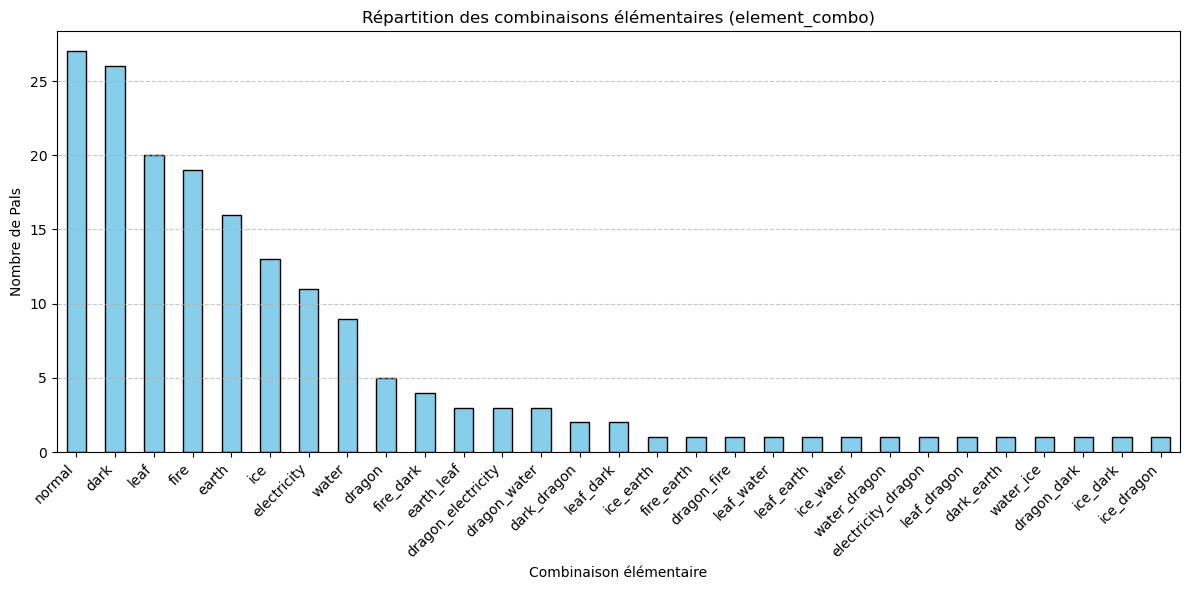

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement des données si nécessaire
df = df_raw.copy()

# Nettoyage des colonnes d’éléments
df["element_1_clean"] = df["Element 1"].str.strip().str.lower().str.replace(" ", "_")
df["element_2_clean"] = df["Element 2"].fillna("").str.strip().str.lower().str.replace(" ", "_")

df["element_2_clean"] = df["element_2_clean"].replace("", pd.NA)

# Création de la colonne de combinaison élémentaire
df["element_combo"] = df.apply(
    lambda row: row["element_1_clean"] + "_" + row["element_2_clean"]
    if pd.notna(row["element_2_clean"])
    else row["element_1_clean"],
    axis=1
)

# Barplot des combinaisons
element_combo_counts = df["element_combo"].value_counts()
plt.figure(figsize=(12, 6))
element_combo_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Répartition des combinaisons élémentaires (element_combo)")
plt.xlabel("Combinaison élémentaire")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [24]:
# Création d’une colonne de combinaison élémentaire
df["element_combo"] = df["element_1_clean"]
df.loc[df["element_2_clean"].notna(), "element_combo"] = df["element_1_clean"] + "_" + df["element_2_clean"]

# Booléen indiquant s'il y a deux éléments
df["has_dual_element"] = df["element_2_clean"].notna()


In [26]:
element_combo_counts = df["element_combo"].value_counts().sort_values(ascending=False)


In [28]:
# Nettoyage de la colonne 'Tribe'
df["tribe_clean"] = df["Tribe"].str.replace("EPalTribeID::", "", regex=False)

# Nettoyage de la colonne 'BPClass' (souvent déjà propre, mais au cas où)
df["bp_class_clean"] = df["BPClass"].str.strip()

# Vérification rapide
df[["Tribe", "tribe_clean", "BPClass", "bp_class_clean"]].head(10)


,Tribe,tribe_clean,BPClass,bp_class_clean
0,EPalTribeID::BlackGriffon,BlackGriffon,GYM_BlackGriffon,GYM_BlackGriffon
1,EPalTribeID::ElecPanda,ElecPanda,GYM_ElecPanda,GYM_ElecPanda
2,EPalTribeID::Horus,Horus,GYM_Horus,GYM_Horus
3,EPalTribeID::LilyQueen,LilyQueen,GYM_LilyQueen,GYM_LilyQueen
4,EPalTribeID::ThunderDragonMan,ThunderDragonMan,GYM_ThunderDragonMan,GYM_ThunderDragonMan
5,EPalTribeID::BadCatgirl,BadCatgirl,BadCatgirl,BadCatgirl
6,EPalTribeID::BlueberryFairy,BlueberryFairy,BlueberryFairy,BlueberryFairy
7,EPalTribeID::Alpaca,Alpaca,BOSS_Alpaca,BOSS_Alpaca
8,EPalTribeID::AmaterasuWolf,AmaterasuWolf,BOSS_AmaterasuWolf,BOSS_AmaterasuWolf
9,EPalTribeID::Anubis,Anubis,Boss_Anubis,Boss_Anubis


In [33]:
# Nettoyage des colonnes Tribe et BPClass
df_raw["tribe_clean"] = df_raw["Tribe"].str.replace("EPalTribeID::", "", regex=False)
df_raw["bp_class_clean"] = df_raw["BPClass"]  # Déjà propre ici, à titre indicatif
# Vérification rapide
df_raw[["Tribe", "tribe_clean", "BPClass", "bp_class_clean"]].head(10)

,Tribe,tribe_clean,BPClass,bp_class_clean
0,EPalTribeID::BlackGriffon,BlackGriffon,GYM_BlackGriffon,GYM_BlackGriffon
1,EPalTribeID::ElecPanda,ElecPanda,GYM_ElecPanda,GYM_ElecPanda
2,EPalTribeID::Horus,Horus,GYM_Horus,GYM_Horus
3,EPalTribeID::LilyQueen,LilyQueen,GYM_LilyQueen,GYM_LilyQueen
4,EPalTribeID::ThunderDragonMan,ThunderDragonMan,GYM_ThunderDragonMan,GYM_ThunderDragonMan
5,EPalTribeID::BadCatgirl,BadCatgirl,BadCatgirl,BadCatgirl
6,EPalTribeID::BlueberryFairy,BlueberryFairy,BlueberryFairy,BlueberryFairy
7,EPalTribeID::Alpaca,Alpaca,BOSS_Alpaca,BOSS_Alpaca
8,EPalTribeID::AmaterasuWolf,AmaterasuWolf,BOSS_AmaterasuWolf,BOSS_AmaterasuWolf
9,EPalTribeID::Anubis,Anubis,Boss_Anubis,Boss_Anubis


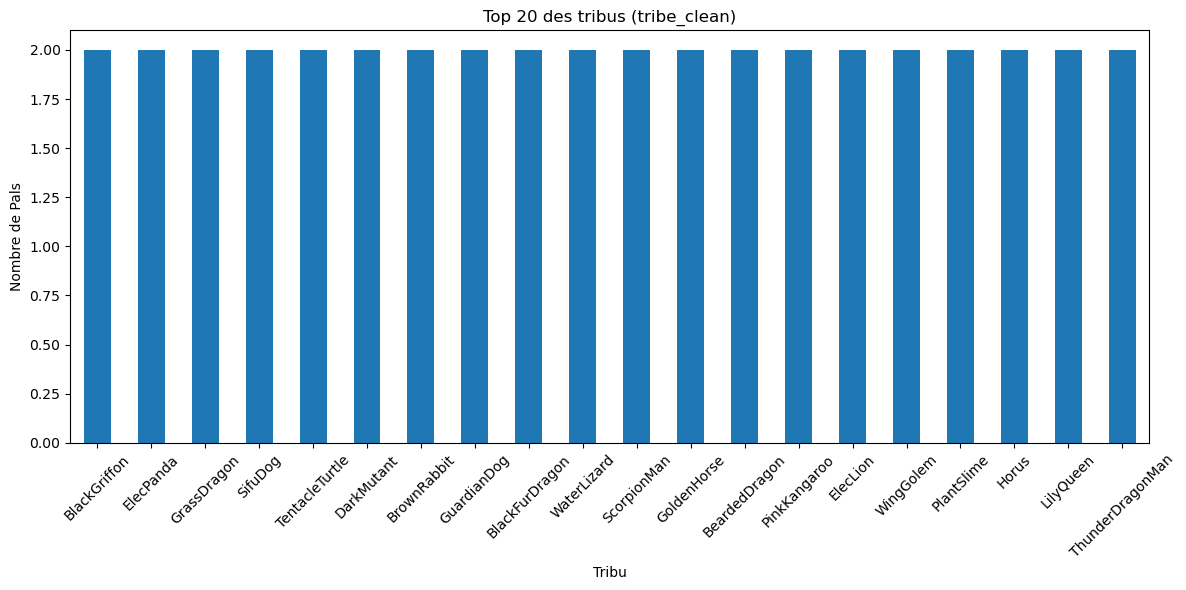

In [32]:
import matplotlib.pyplot as plt

# Répartition des tribus
plt.figure(figsize=(12, 6))
df["tribe_clean"].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 des tribus (tribe_clean)")
plt.xlabel("Tribu")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


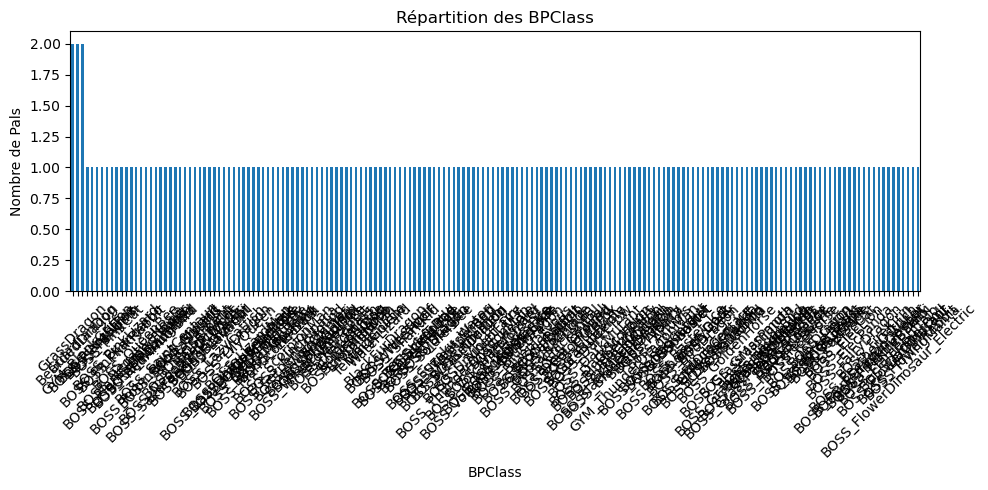

In [34]:
plt.figure(figsize=(10, 5))
df_raw["bp_class_clean"].value_counts().plot(kind='bar')
plt.title("Répartition des BPClass")
plt.xlabel("BPClass")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


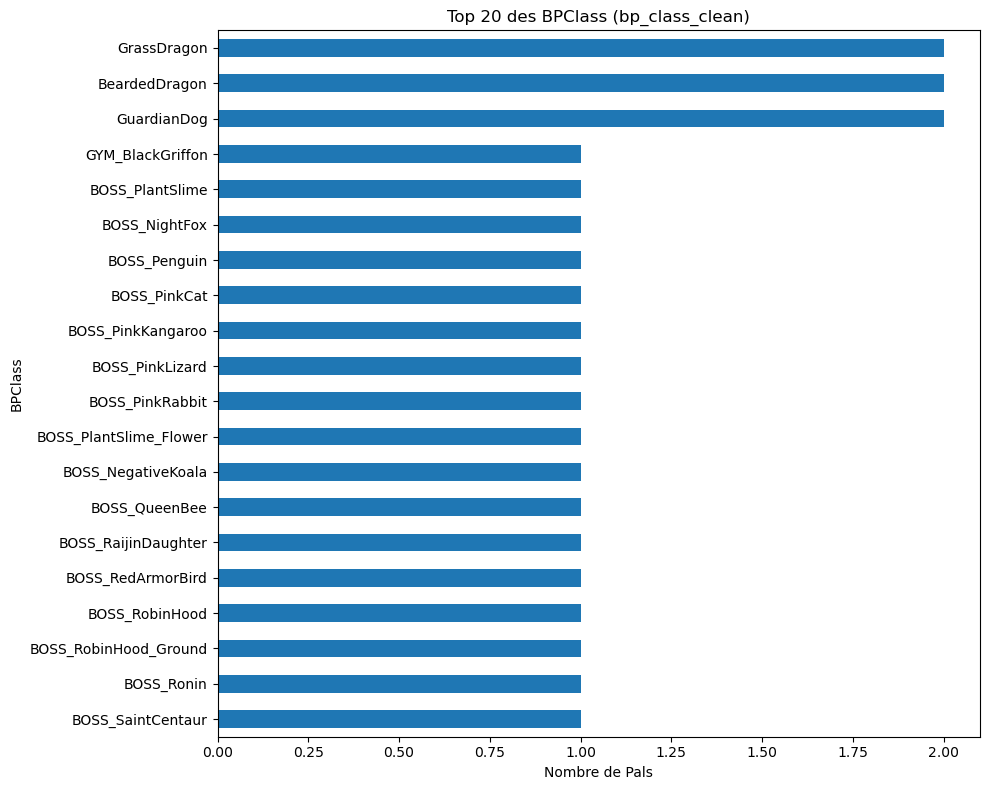

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
df_raw["bp_class_clean"].value_counts().head(20).plot(kind='barh')
plt.title("Top 20 des BPClass (bp_class_clean)")
plt.xlabel("Nombre de Pals")
plt.ylabel("BPClass")
plt.gca().invert_yaxis()  # Pour avoir le plus fréquent en haut
plt.tight_layout()
plt.show()


Statistiques de la colonne 'price' :
count      177.000000
mean      4521.468927
std       2894.269041
min       1000.000000
25%       1840.000000
50%       4040.000000
75%       6830.000000
max      10520.000000
Name: price, dtype: float64

Valeurs les plus fréquentes :
price
1000     6
6720     4
8440     4
6510     3
10380    3
Name: count, dtype: int64


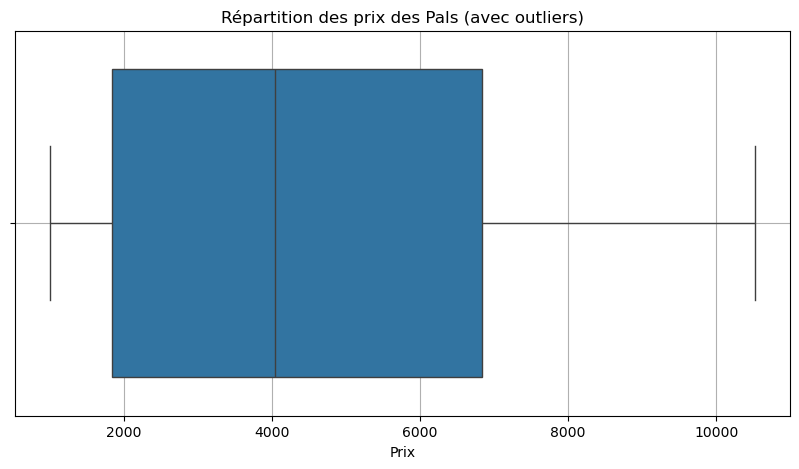

In [36]:
# Statistiques descriptives
print("Statistiques de la colonne 'price' :")
print(df["price"].describe())

# Valeurs uniques les plus fréquentes
print("\nValeurs les plus fréquentes :")
print(df["price"].value_counts().head())

# Vérifions s’il y a des valeurs aberrantes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["price"])
plt.title("Répartition des prix des Pals (avec outliers)")
plt.xlabel("Prix")
plt.grid(True)
plt.show()


In [37]:
# Création de la colonne 'price_category'
df["price_category"] = pd.cut(
    df["price"],
    bins=[0, 2000, 6000, float("inf")],
    labels=["Bas", "Moyen", "Élevé"]
)

# Vérification rapide
print(df[["code name", "price", "price_category"]].head(10))


              code name  price price_category
0      GYM_BlackGriffon   9060          Élevé
1         GYM_ElecPanda   6610          Élevé
2             GYM_Horus   6720          Élevé
3         GYM_LilyQueen   6510          Élevé
4  GYM_ThunderDragonMan   8320          Élevé
5            BadCatgirl   4690          Moyen
6        BlueberryFairy   8200          Élevé
7           BOSS_Alpaca   3040          Moyen
8    BOSS_AmaterasuWolf   3170          Moyen
9           Boss_Anubis   9190          Élevé


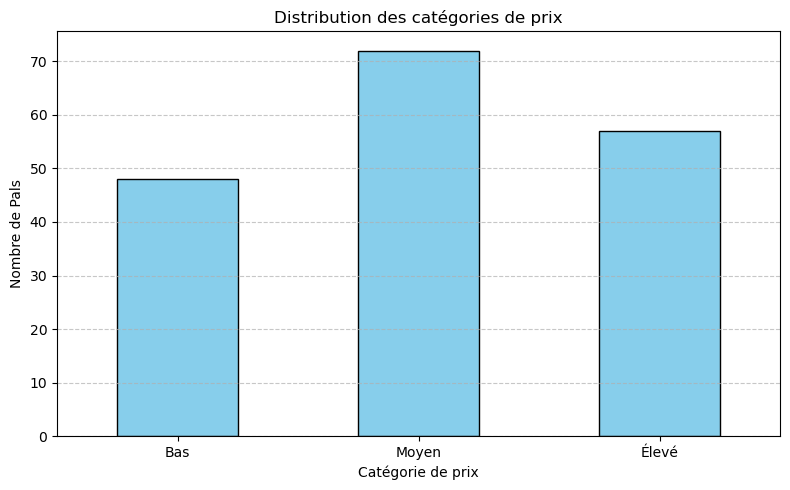

In [44]:
import matplotlib.pyplot as plt

# Comptage des catégories
price_counts = df["price_category"].value_counts().sort_index()

# Barplot
plt.figure(figsize=(8, 5))
price_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution des catégories de prix")
plt.xlabel("Catégorie de prix")
plt.ylabel("Nombre de Pals")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


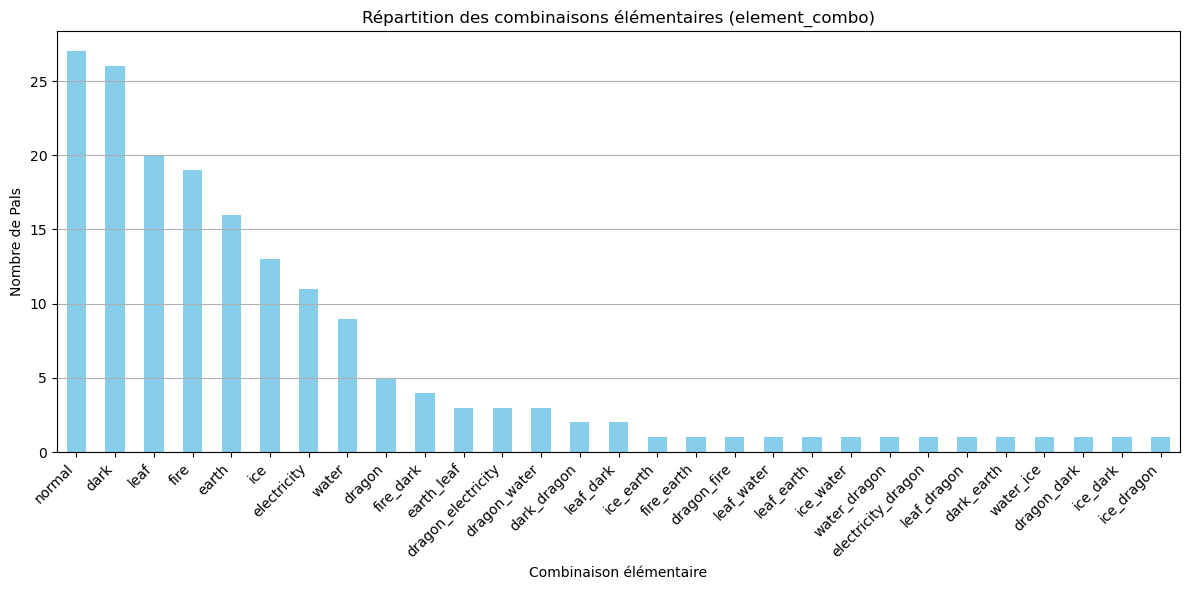

In [47]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les données brutes
file_path = "../data/raw/Palworld_Data-hide pallu attributes.csv"
df_raw = pd.read_csv(file_path)

# Copier les données pour nettoyage
df = df_raw.copy()

# Nettoyage des colonnes élémentaires
df["element_1_clean"] = df["Element 1"].str.strip().str.lower().str.replace(" ", "_")
df["element_2_clean"] = df["Element 2"].fillna("").str.strip().str.lower().str.replace(" ", "_")

# Option 2 : remplacer les chaînes vides par pd.NA de façon sûre
df.replace({"element_2_clean": {"": pd.NA}}, inplace=True)

# Création de la combinaison élémentaire
df["element_combo"] = df.apply(
    lambda row: row["element_1_clean"] + "_" + row["element_2_clean"]
    if pd.notna(row["element_2_clean"])
    else row["element_1_clean"],
    axis=1
)

# Indicateur d'élément double
df["has_dual_element"] = df["element_2_clean"].notna()

# Visualisation de la répartition des combinaisons élémentaires
plt.figure(figsize=(12, 6))
df["element_combo"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Répartition des combinaisons élémentaires (element_combo)")
plt.xlabel("Combinaison élémentaire")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis='y')
plt.show()


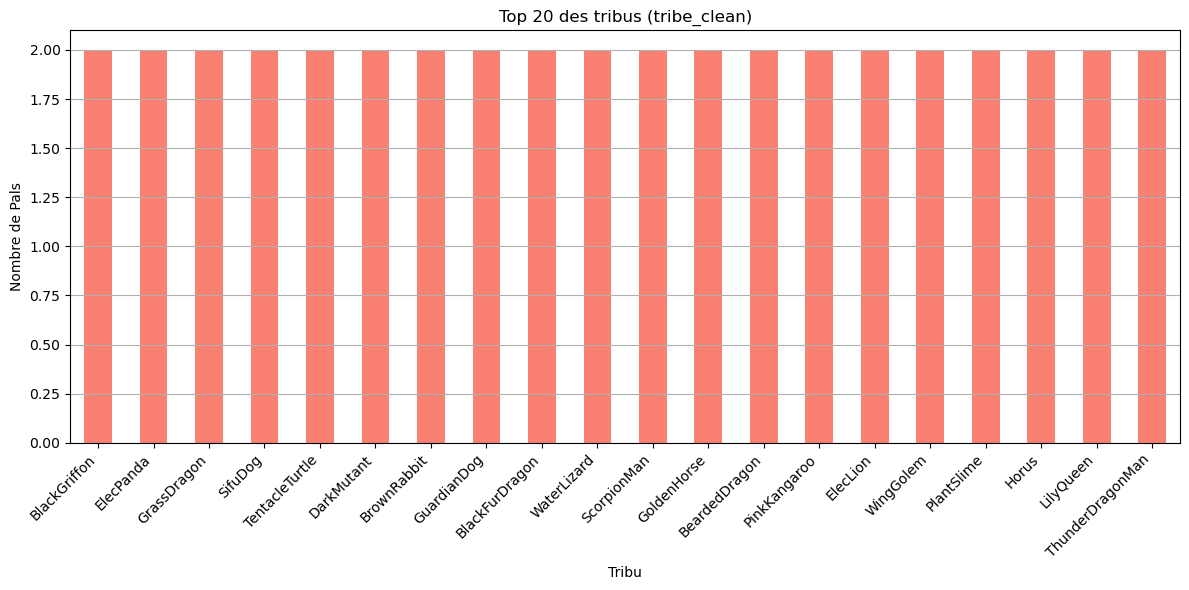

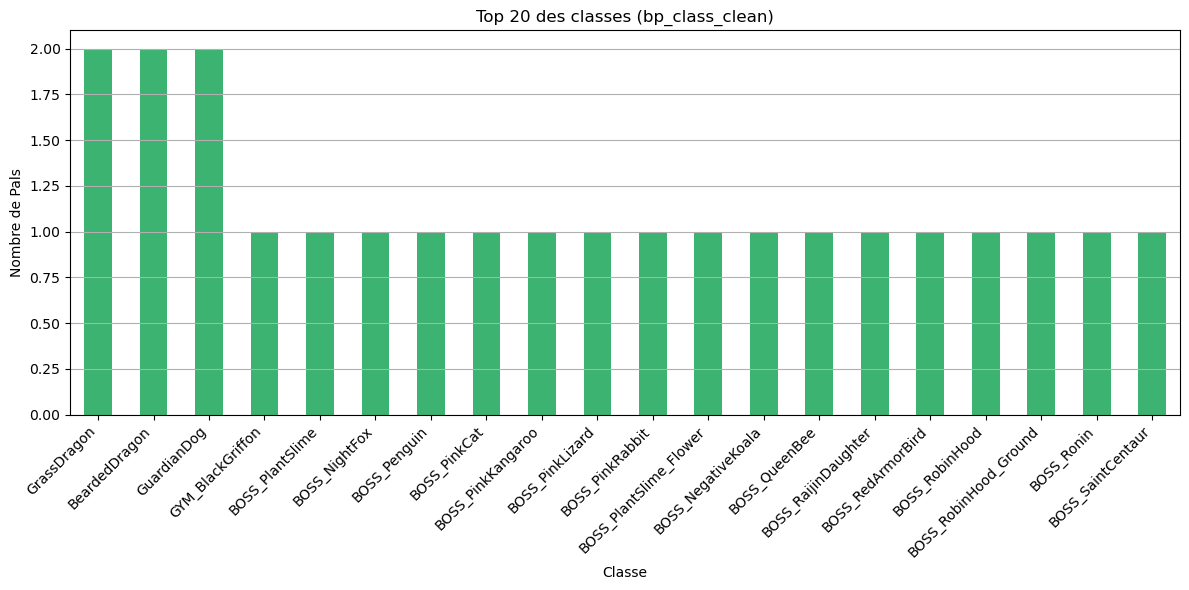

In [46]:
# 🧼 Nettoyage des colonnes Tribe et BPClass
df["tribe_clean"] = df["Tribe"].str.replace("EPalTribeID::", "", regex=False)
df["bp_class_clean"] = df["BPClass"].astype(str).str.strip()

# 📊 Visualisation des tribus
plt.figure(figsize=(12, 6))
df["tribe_clean"].value_counts().head(20).plot(kind="bar", color="salmon")
plt.title("Top 20 des tribus (tribe_clean)")
plt.xlabel("Tribu")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# 📊 Visualisation des classes BP
plt.figure(figsize=(12, 6))
df["bp_class_clean"].value_counts().head(20).plot(kind="bar", color="mediumseagreen")
plt.title("Top 20 des classes (bp_class_clean)")
plt.xlabel("Classe")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [48]:
# Valeurs uniques triées + nombre d'occurrences
weapon_counts = df["weapon"].value_counts()
print("Valeurs uniques dans la colonne 'weapon' :\n")
print(weapon_counts)


Valeurs uniques dans la colonne 'weapon' :

weapon
EPalWeaponType::None    177
Name: count, dtype: int64


In [49]:
df.drop(columns=["weapon"], inplace=True)
print("Colonne 'weapon' supprimée (aucune variabilité).")


Colonne 'weapon' supprimée (aucune variabilité).


Distribution de WeaponEquip :
WeaponEquip
False    177
Name: count, dtype: int64


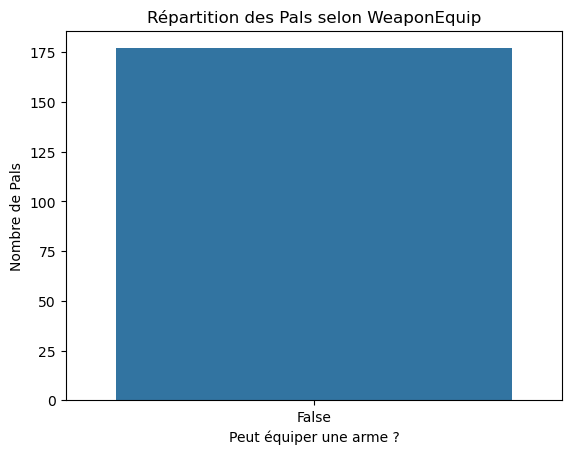

In [50]:
# Distribution de WeaponEquip
print("Distribution de WeaponEquip :")
print(df["WeaponEquip"].value_counts(dropna=False))

# Visualisation rapide
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="WeaponEquip")
plt.title("Répartition des Pals selon WeaponEquip")
plt.xlabel("Peut équiper une arme ?")
plt.ylabel("Nombre de Pals")
plt.show()


## Croiser WeaponEquip avec IsBoss

In [51]:
# Croisement avec IsBoss
cross_tab = pd.crosstab(df["WeaponEquip"], df["IsBoss"])
print(cross_tab)

# En % pour mieux lire
cross_tab_pct = pd.crosstab(df["WeaponEquip"], df["IsBoss"], normalize="index") * 100
print(cross_tab_pct)


IsBoss       False  True 
WeaponEquip              
False           17    160
IsBoss         False     True 
WeaponEquip                   
False        9.60452  90.39548


In [57]:
print(df.columns.tolist())


['Chinese name', 'code name', 'OverrideNameTextID', 'NamePrefixID', 'OverridePartnerSkillTextID', 'IsPal', 'Tribe', 'BPClass', 'Pictorial ID', 'ZukanIndexSuffix', 'Size', 'rarity', 'Element 1', 'Element 2', 'GenusCategory', 'Organization', 'WeaponEquip', 'HP', 'melee attack', 'Remote attack', 'defense', 'support', 'CraftSpeed', '(being) damage multiplier', 'Capture probability', 'Experience multiplier', 'price', 'AIRResponse', 'AISightResponse', 'slow walking speed', 'walking speed', 'running speed', 'Riding sprint speed', 'Handling speed', 'IsBoss', 'IsTowerBoss', 'BattleBGM', 'IgnoreLeanBack', 'IgnoreBlowAway', 'MaxFullStomach', 'FullStomachDecreaseRate', 'FoodAmount', 'ViewingDistance', 'ViewingAngle', 'HearingRate', 'NooseTrap', 'Nocturnal', 'BiologicalGrade', 'Predator', 'Edible', 'endurance', 'Male probability', 'fecundity', 'Breathing fire', 'watering', 'planting', 'generate electricity', 'manual', 'collection', 'logging', 'Mining', 'OilExtraction (not shown in game)', 'pharmace

In [58]:
if "weapon" in df.columns:
    print("weapon est là.")
else:
    print("weapon n'existe pas dans ce DataFrame.")


weapon n'existe pas dans ce DataFrame.


In [54]:
# Croisement entre weapon et IsBoss
weapon_boss_ct = df.groupby(["weapon", "IsBoss"]).size().unstack(fill_value=0)

# Affichage du tableau croisé
print("Répartition des Pals armés/non-armés selon leur statut Boss :")
display(weapon_boss_ct)


KeyError: 'weapon'

## Croiser avec price (valeurs et stats)

In [52]:
# Statistiques du prix selon WeaponEquip
df.groupby("WeaponEquip")["price"].describe()


,count,mean,std,min,25%,50%,75%,max
WeaponEquip,,,,,,,,
False,177.0,4521.468927,2894.269041,1000.0,1840.0,4040.0,6830.0,10520.0


In [55]:
# Prix moyen selon l'équipement
weapon_price_stats = df.groupby("weapon")["price"].agg(["count", "mean", "min", "max"]).sort_values(by="mean", ascending=False)

print("Statistiques de prix selon l’équipement :")
display(weapon_price_stats)


KeyError: 'weapon'

##  Créer une catégorie stratégique

In [53]:
df["weapon_type_category"] = df["WeaponEquip"].map({True: "Armable", False: "Non armable"})


In [60]:
print("weapon" in df_raw.columns)  # doit renvoyer True


True


In [61]:
df = df.merge(df_raw[["code name", "weapon"]], on="code name", how="left")


In [62]:
print(df["weapon"].value_counts())


weapon
EPalWeaponType::None    177
Name: count, dtype: int64


In [63]:
# Liste des colonnes de stats de combat
combat_stats = ["HP", "melee attack", "Remote attack", "defense", "support", "CraftSpeed"]

# Statistiques descriptives
df[combat_stats].describe()


,HP,melee attack,Remote attack,defense,support,CraftSpeed
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.0
mean,282.005650,95.819209,94.858757,91.016949,99.661017,100.0
std,1073.466171,17.662591,20.480238,20.242416,12.698349,0.0
min,60.000000,50.000000,50.000000,50.000000,30.000000,100.0
25%,80.000000,80.000000,80.000000,80.000000,100.000000,100.0
50%,100.000000,100.000000,95.000000,90.000000,100.000000,100.0
75%,105.000000,100.000000,105.000000,100.000000,100.000000,100.0
max,8000.000000,150.000000,200.000000,220.000000,150.000000,100.0


## Histogrammes des stats de combat

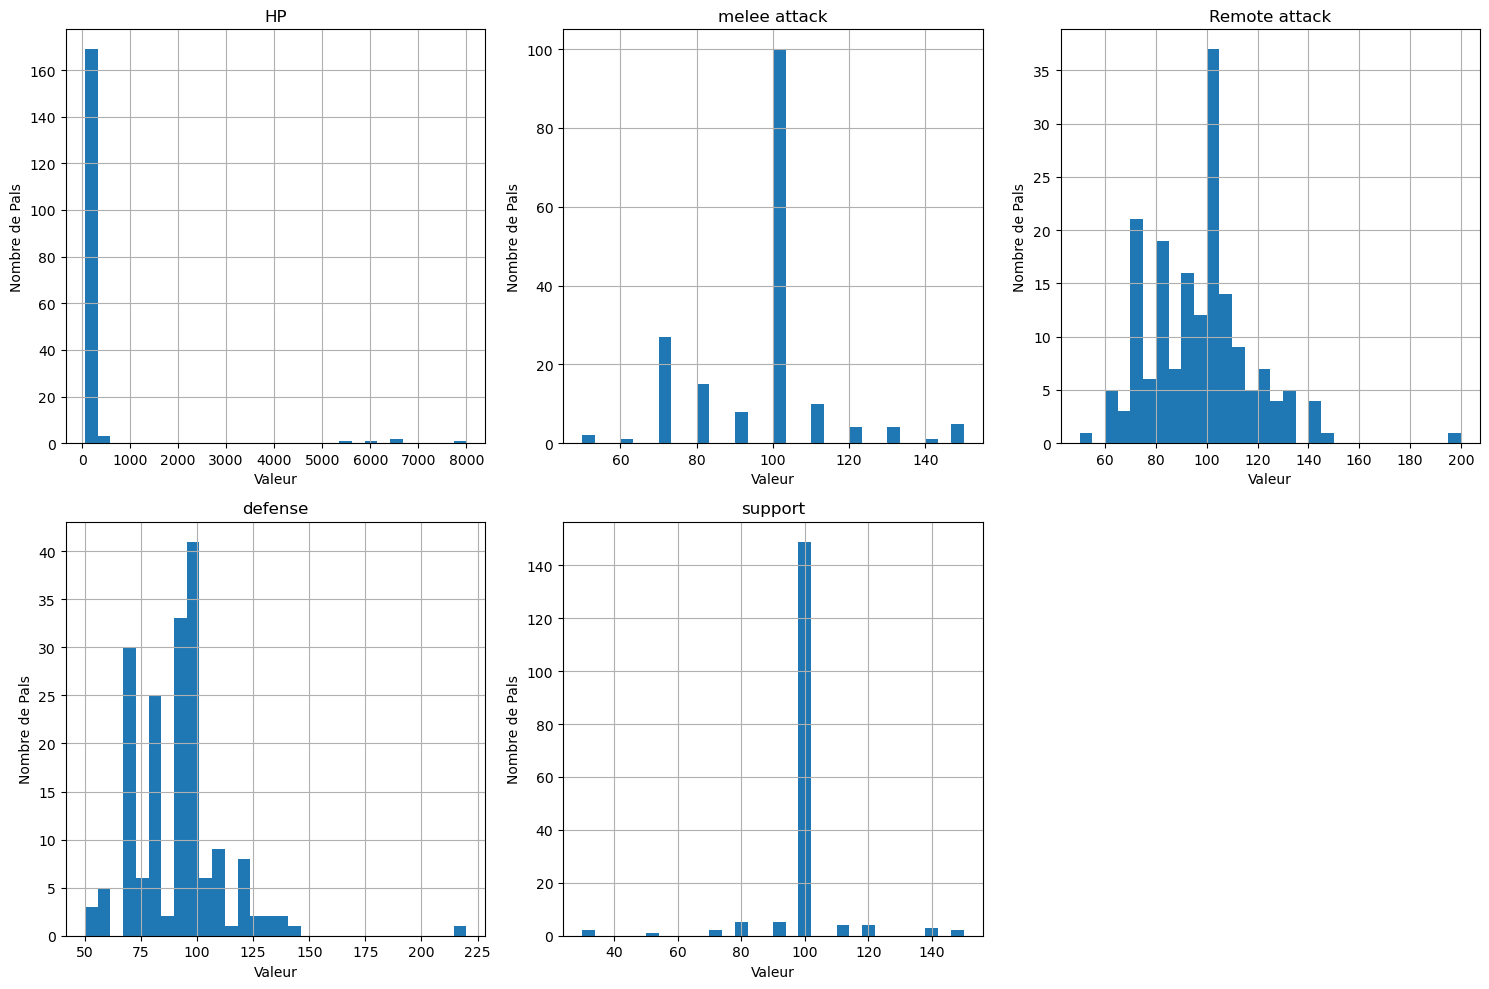

In [64]:
import matplotlib.pyplot as plt

combat_stats = ["HP", "melee attack", "Remote attack", "defense", "support"]

plt.figure(figsize=(15, 10))

for i, stat in enumerate(combat_stats, 1):
    plt.subplot(2, 3, i)
    df[stat].hist(bins=30)
    plt.title(stat)
    plt.xlabel("Valeur")
    plt.ylabel("Nombre de Pals")
    plt.grid(True)

plt.tight_layout()
plt.show()


## Visualisation avec Boxplots

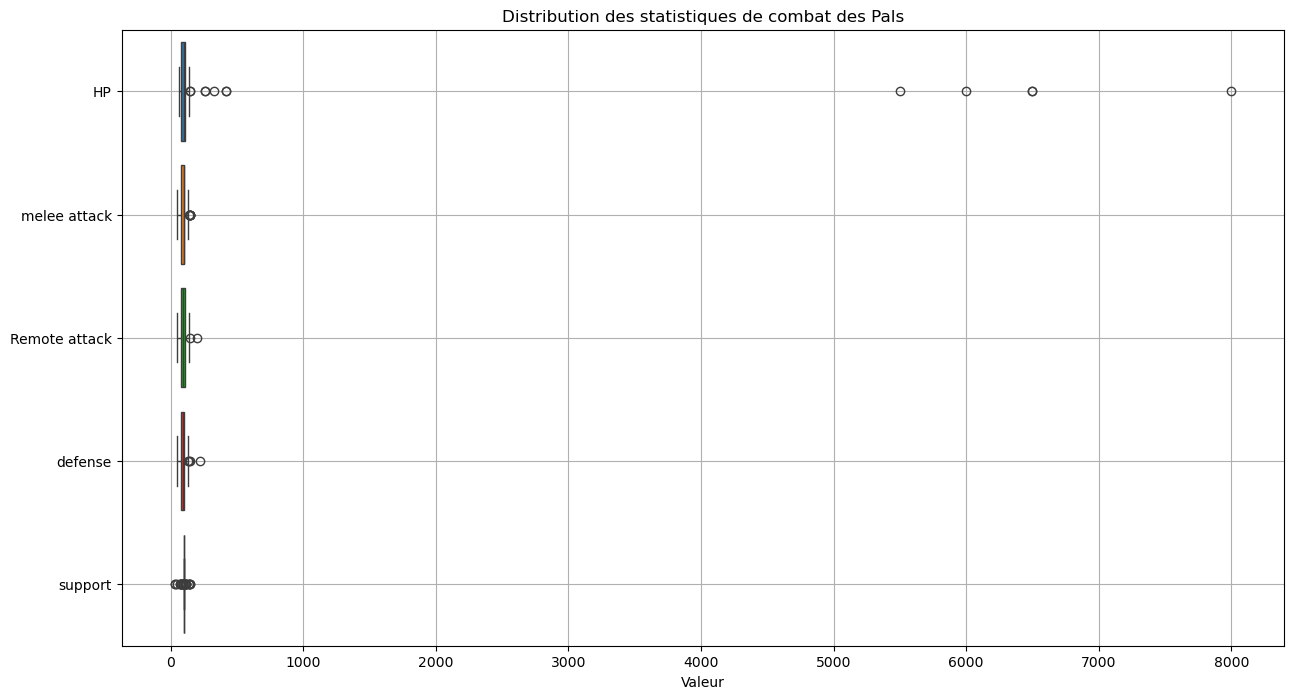

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

combat_stats = ["HP", "melee attack", "Remote attack", "defense", "support"]

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[combat_stats], orient="h")
plt.title("Distribution des statistiques de combat des Pals")
plt.xlabel("Valeur")
plt.grid(True)
plt.show()


## Catégorisation des Pals (ex: HP élevé, moyen, faible)



In [67]:
# Créer une nouvelle colonne catégorielle pour HP
df["HP_category"] = pd.qcut(df["HP"], q=3, labels=["Faible", "Moyen", "Élevé"])

# Aperçu
df[["code name", "HP", "HP_category"]].sort_values(by="HP", ascending=False).head(10)


,code name,HP,HP_category
0,GYM_BlackGriffon,8000,Élevé
2,GYM_Horus,6500,Élevé
4,GYM_ThunderDragonMan,6500,Élevé
1,GYM_ElecPanda,6000,Élevé
3,GYM_LilyQueen,5500,Élevé
85,BOSS_IceHorse_Dark,420,Élevé
84,BOSS_IceHorse,420,Élevé
86,BOSS_JetDragon,330,Élevé
126,BOSS_SaintCentaur,260,Élevé
19,BOSS_BlackCentaur,260,Élevé


## Catégorisation des autres stats

In [72]:
combat_stats = ["melee attack", "Remote attack", "defense", "support", "CraftSpeed"]

for col in combat_stats:
    unique_vals = df[col].nunique()
    if unique_vals >= 2:
        try:
            # Calculer les quantiles avec suppression des doublons
            bins = df[col].quantile([0, 1/3, 2/3, 1.0]).unique()
            n_bins = len(bins) - 1

            if n_bins >= 2:
                labels = ["Faible", "Moyen", "Élevé"][:n_bins]
                cat_col = f"{col.replace(' ', '_')}_category"
                df[cat_col] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
            else:
                print(f"Trop peu de bins uniques pour : {col}")
        except Exception as e:
            print(f"Erreur avec la colonne {col} : {e}")
    else:
        print(f"Colonne ignorée : {col} (valeurs distinctes = {unique_vals})")


Colonne ignorée : CraftSpeed (valeurs distinctes = 1)


## Visualisation croisée : type de Pal vs. puissance

In [69]:
# Exemple : Croisement entre HP_category et tribe_clean
hp_tribe_ct = pd.crosstab(df["tribe_clean"], df["HP_category"])
hp_tribe_ct.plot(kind="barh", stacked=True, figsize=(10, 12), colormap="viridis")
plt.title("Répartition des Pals par tribu et niveau de HP")
plt.xlabel("Nombre de Pals")
plt.ylabel("Tribu")
plt.legend(title="HP Category")
plt.tight_layout()
plt.grid(True)
plt.show()


KeyError: 'tribe_clean'

## Aperçu des nouvelles colonnes de catégories créées


In [73]:
combat_stats = ["HP", "melee attack", "Remote attack", "defense", "support"]

# Affichage d'un extrait avec les colonnes originales + catégories
df[["code name"] + combat_stats + [f"{col.replace(' ', '_')}_category" for col in combat_stats]].head(10)


,code name,HP,melee attack,Remote attack,defense,support,HP_category,melee_attack_category,Remote_attack_category,defense_category,support_category
0,GYM_BlackGriffon,8000,130,200,220,90,Élevé,Moyen,Élevé,Élevé,Faible
1,GYM_ElecPanda,6000,100,100,100,100,Élevé,Faible,Moyen,Moyen,Faible
2,GYM_Horus,6500,100,120,125,90,Élevé,Faible,Élevé,Élevé,Faible
3,GYM_LilyQueen,5500,100,110,105,100,Élevé,Faible,Élevé,Élevé,Faible
4,GYM_ThunderDragonMan,6500,100,140,110,100,Élevé,Faible,Élevé,Élevé,Faible
5,BadCatgirl,100,100,90,90,100,Moyen,Faible,Moyen,Moyen,Faible
6,BlueberryFairy,100,100,100,100,100,Moyen,Faible,Moyen,Moyen,Faible
7,BOSS_Alpaca,90,90,90,90,100,Faible,Faible,Moyen,Moyen,Faible
8,BOSS_AmaterasuWolf,100,70,115,100,110,Moyen,Faible,Élevé,Moyen,Moyen
9,Boss_Anubis,120,130,130,100,100,Élevé,Moyen,Élevé,Moyen,Faible


## Croisement visuel de 2 catégories (ex. HP vs defense)


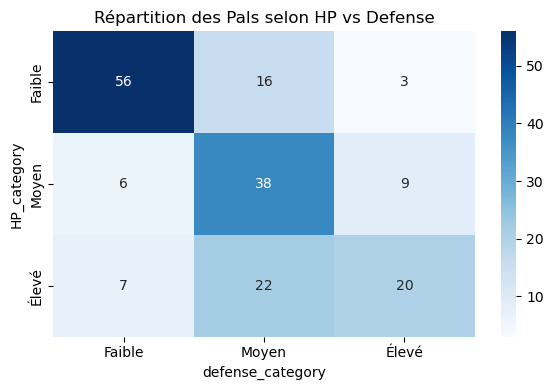

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tableau croisé
ct = pd.crosstab(df["HP_category"], df["defense_category"])

# Affichage
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, cmap="Blues", fmt="d")
plt.title("Répartition des Pals selon HP vs Defense")
plt.xlabel("defense_category")
plt.ylabel("HP_category")
plt.tight_layout()
plt.show()


## Crosstab entre HP_category et defense_category 

In [77]:
pd.crosstab(df["HP_category"], df["defense_category"])


defense_category,Faible,Moyen,Élevé
HP_category,,,
Faible,56,16,3
Moyen,6,38,9
Élevé,7,22,20


##  OP Tanks (HP + défense élevées)

In [79]:
op_tanks = df[
    (df["HP_category"] == "Élevé") &
    (df["defense_category"] == "Élevé")
]
display(op_tanks[["code name", "HP", "defense", "HP_category", "defense_category"]])


,code name,HP,defense,HP_category,defense_category
0,GYM_BlackGriffon,8000,220,Élevé,Élevé
2,GYM_Horus,6500,125,Élevé,Élevé
3,GYM_LilyQueen,5500,105,Élevé,Élevé
4,GYM_ThunderDragonMan,6500,110,Élevé,Élevé
19,BOSS_BlackCentaur,260,120,Élevé,Élevé
20,BOSS_BlackFurDragon,130,110,Élevé,Élevé
21,BOSS_BlackGriffon,120,140,Élevé,Élevé
80,BOSS_HerculesBeetle,120,120,Élevé,Élevé
84,BOSS_IceHorse,420,120,Élevé,Élevé
85,BOSS_IceHorse_Dark,420,135,Élevé,Élevé


## Snipers (attaque à distance élevée, faible PV)

In [80]:
snipers = df[
    (df["Remote_attack_category"] == "Élevé") &
    (df["HP_category"] == "Faible")
]
display(snipers[["code name", "Remote attack", "HP", "Remote_attack_category", "HP_category"]])


,code name,Remote attack,HP,Remote_attack_category,HP_category
17,BOSS_BirdDragon,115,90,Élevé,Faible
18,BOSS_BirdDragon_Ice,120,90,Élevé,Faible
31,BOSS_CatMage,105,90,Élevé,Faible
63,BOSS_FoxMage,110,90,Élevé,Faible
66,BOSS_GhostBeast,105,75,Élevé,Faible
74,BOSS_GrassRabbitMan,115,90,Élevé,Faible
92,BOSS_Kirin,105,80,Élevé,Faible
120,BOSS_QueenBee,105,90,Élevé,Faible
123,BOSS_RobinHood,105,90,Élevé,Faible
124,BOSS_RobinHood_Ground,105,90,Élevé,Faible


## Glass Cannons (attaque physique élevée, faible défense)

In [81]:
glass_cannons = df[
    (df["melee_attack_category"] == "Élevé") &
    (df["defense_category"] == "Faible")
]
display(glass_cannons[["code name", "melee attack", "defense", "melee_attack_category", "defense_category"]])


,code name,melee attack,defense,melee_attack_category,defense_category


In [83]:
import pandas as pd

# Remplacer par le bon chemin si nécessaire
df = pd.read_csv("../data/clean_hidden_attribute.csv")


FileNotFoundError: [Errno 2] No such file or directory: '../data/clean_hidden_attribute.csv'

## Visualiser les profils stratégiques – Scatterplots

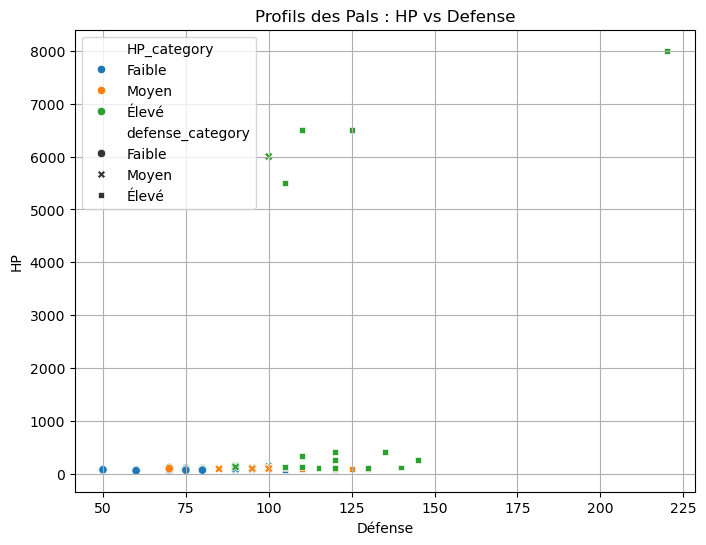

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exemple : Scatterplot HP vs Defense
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="defense", y="HP", hue="HP_category", style="defense_category")
plt.title("Profils des Pals : HP vs Defense")
plt.xlabel("Défense")
plt.ylabel("HP")
plt.grid(True)
plt.show()


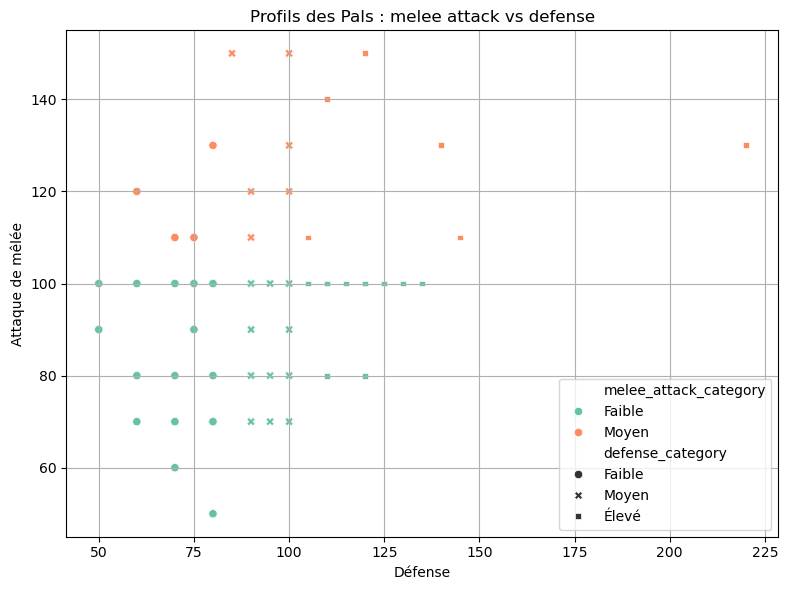

In [85]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="defense",
    y="melee attack",
    hue="melee_attack_category",
    style="defense_category",
    palette="Set2"
)
plt.title("Profils des Pals : melee attack vs defense")
plt.xlabel("Défense")
plt.ylabel("Attaque de mêlée")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Ce graphe nous aide à repérer :
-les tanks offensifs (melee élevé + défense élevée),
-les glass cannons (melee élevé + défense faible),
-les protecteurs passifs (melee faible + défense élevée).

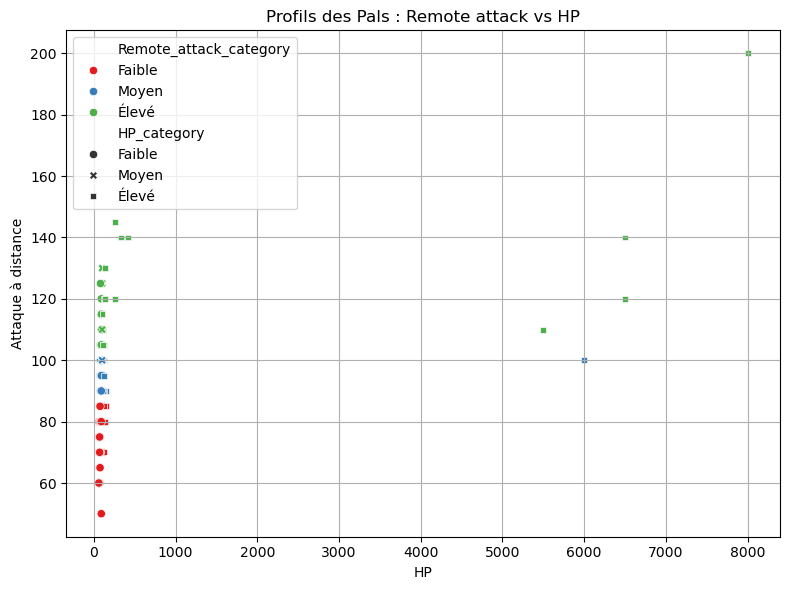

In [87]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="HP",
    y="Remote attack",
    hue="Remote_attack_category",
    style="HP_category",
    palette="Set1"
)
plt.title("Profils des Pals : Remote attack vs HP")
plt.xlabel("HP")
plt.ylabel("Attaque à distance")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Ce graphique te permettra de visualiser les :

-snipers → Remote attack élevé + HP faible,
-bulky shooters → Remote élevé + HP élevé,
-fragiles → Remote faible + HP faible.

## Heatmap des corrélations entre stats brutes

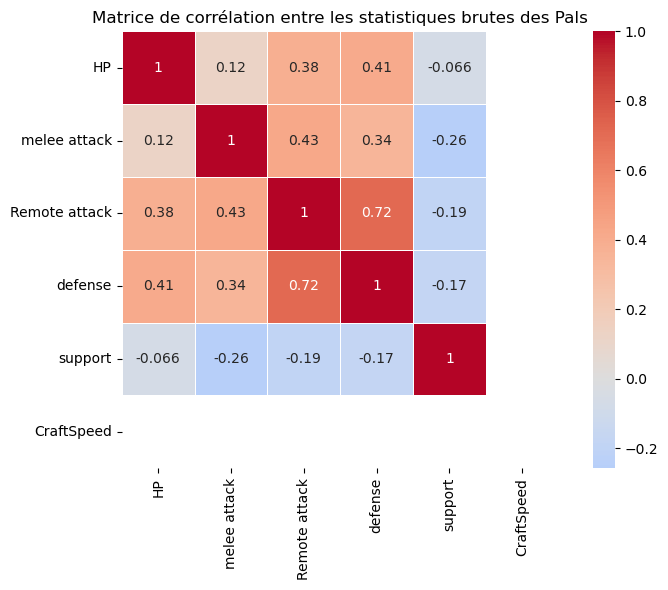

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des colonnes numériques de combat
combat_stats_cols = ["HP", "melee attack", "Remote attack", "defense", "support", "CraftSpeed"]

# Calcul de la matrice de corrélation
corr_matrix = df[combat_stats_cols].corr()

# Affichage de la heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matrice de corrélation entre les statistiques brutes des Pals")
plt.tight_layout()
plt.show()


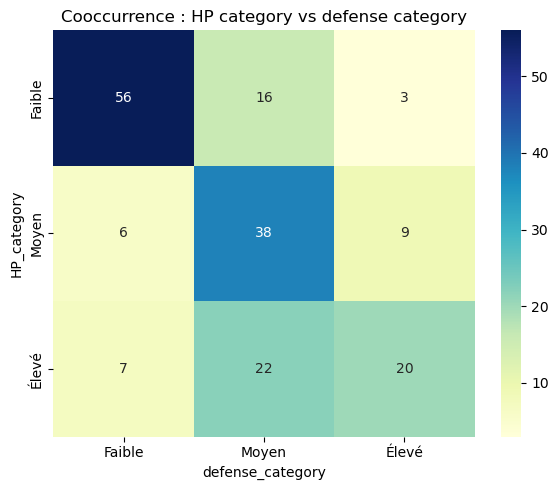

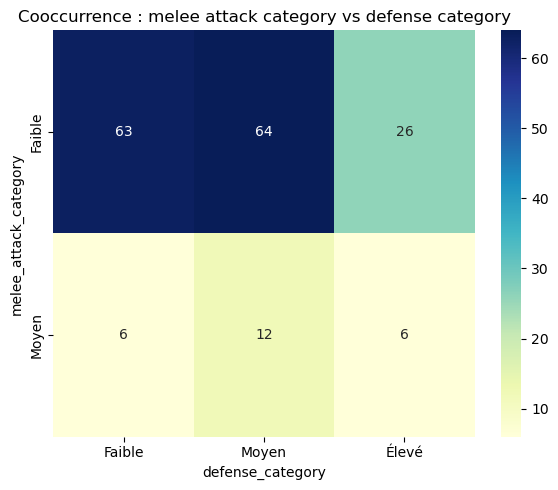

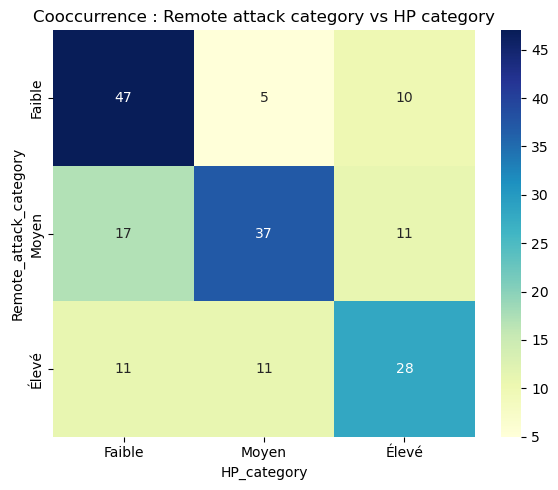

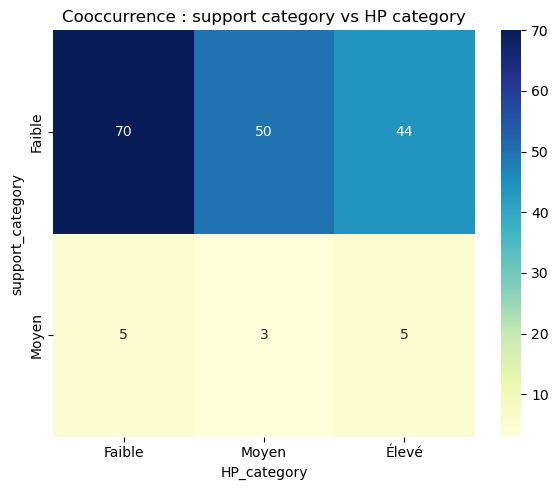

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

# Liste des combinaisons à explorer
category_pairs = [
    ("HP_category", "defense_category"),
    ("melee_attack_category", "defense_category"),
    ("Remote_attack_category", "HP_category"),
    ("support_category", "HP_category")
]

# Générer les heatmaps
for cat_x, cat_y in category_pairs:
    crosstab = pd.crosstab(df[cat_x], df[cat_y])
    plt.figure(figsize=(6, 5))
    sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(f"Cooccurrence : {cat_x.replace('_', ' ')} vs {cat_y.replace('_', ' ')}")
    plt.xlabel(cat_y)
    plt.ylabel(cat_x)
    plt.tight_layout()
    plt.show()
